In [2]:
import matplotlib.pyplot as plt
from sklearn import pipeline
from rdkit import Chem
import seaborn as sns
import pandas as pd
import numpy as np
import sklearn
import scipy

In [3]:
def get_high_corr(X):
    corr_matrix = X.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    return (
        upper.unstack()
        .dropna()
        .sort_values(ascending=False)
    )

In [4]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_even_more_qm2.csv")

In [5]:
df.columns

Index(['id', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'fr_sulfone', 'fr_term_acetylene', 'fr_tetrazole', 'fr_thiazole',
       'fr_thiocyan', 'fr_thiophene', 'fr_unbrch_alkane', 'fr_urea',
       'canon_smiles', 'solubility'],
      dtype='str', length=354)

In [6]:
y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [7]:
high_corr = get_high_corr(X)

In [8]:
high_corr[high_corr > 0.95].head(50)

fr_amide                              NumAmideBonds                           1.000000
fr_Nhpyrrole                          fr_Ar_NH                                1.000000
solvation_energy_dmso                 solvation_energy_water                  1.000000
min_partial_charge_dmso               min_partial_charge_water                1.000000
std_partial_charge_dmso               std_partial_charge_water                1.000000
max_partial_charge_dmso               max_partial_charge_water                0.999998
MaxEStateIndex                        MaxAbsEStateIndex                       0.999997
ExactMolWt                            MolWt                                   0.999987
solvation_energy_dmso                 solvation_energy_thf                    0.999986
solvation_energy_thf                  solvation_energy_water                  0.999984
min_partial_charge_dmso               min_partial_charge_thf                  0.999957
std_partial_charge_dmso               std_p

There seem to be quite a lot of features that correlate perfectly with each other (Pearson correlation of 1). There also seem to be some features that essentially say the same thing, like MolWt and ExactMolWt. As they serve no purpose besides increasing the amount of dimensions of our data, we can remove them. 

In [17]:
energy_corr = X.corr()["SlogP_VSA2"].sort_values()
energy_corr.abs().sort_values(ascending=False).head(50)

SlogP_VSA2                         1.000000
PEOE_VSA1                          0.792035
NumHAcceptors                      0.784334
NOCount                            0.760551
SMR_VSA1                           0.732348
TPSA                               0.696485
EState_VSA1                        0.677756
NumHeteroatoms                     0.652822
SMR_VSA6                           0.637708
NumAtomStereoCenters               0.594382
NumValenceElectrons                0.589722
fr_Al_OH                           0.578419
BCUT2D_LOGPLOW                     0.577323
fr_Al_OH_noTert                    0.571387
Kappa1                             0.571032
Chi0                               0.569878
EState_VSA10                       0.564144
NumHDonors                         0.559384
ir_mode_count_1500                 0.558586
VSA_EState3                        0.557571
NumSaturatedHeterocycles           0.554441
HeavyAtomCount                     0.551591
NumAliphaticHeterocycles        

Index(['SMR_VSA8', 'SlogP_VSA9'], dtype='str')


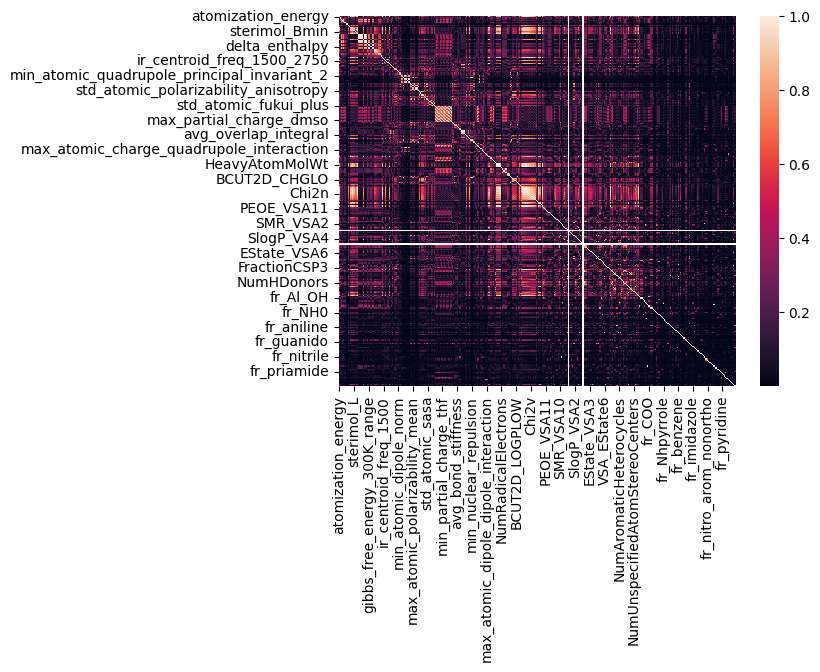

In [10]:
corr = X.corr().abs()

sns.heatmap(corr)
print(X.columns[X.std() == 0])

The Pearson correlation plot reveals there are two features that correlate with 0 other features: `"SMR_VSA8"` and `"SlogP_SVA9"`. This is because these features are constant. They can be removed as they provide zero information to the model.

In [11]:
@np.vectorize
def get_redundant_cols(column):
    return (
        ("solvation_energy" in column and column != "solvation_energy_water") 
        or "avg_partial_charge_" in column 
        or column in ("avg_atomic_fukui_minus", "fr_Nhpyrrole", "NumAmideBonds", "MolWt", "SMR_VSA8", "SlogP_VSA9")
    )

In [12]:
drop_cols = X.columns[get_redundant_cols(X.columns)]
drop_cols, len(drop_cols)

(Index(['solvation_energy_thf', 'solvation_energy_cyclohexane',
        'solvation_energy_dmso', 'MolWt', 'SMR_VSA8', 'SlogP_VSA9',
        'NumAmideBonds', 'fr_Nhpyrrole'],
       dtype='str'),
 8)

In [13]:
new_X = X.drop(drop_cols, axis=1, errors="ignore")

In [14]:
high_corr = get_high_corr(new_X)

high_corr[high_corr > 0.95].head(n=50)

min_partial_charge_dmso               min_partial_charge_water                1.000000
std_partial_charge_dmso               std_partial_charge_water                1.000000
max_partial_charge_dmso               max_partial_charge_water                0.999998
MaxEStateIndex                        MaxAbsEStateIndex                       0.999997
min_partial_charge_dmso               min_partial_charge_thf                  0.999957
std_partial_charge_dmso               std_partial_charge_thf                  0.999955
min_partial_charge_thf                min_partial_charge_water                0.999950
std_partial_charge_thf                std_partial_charge_water                0.999948
max_partial_charge_dmso               max_partial_charge_thf                  0.999756
max_partial_charge_thf                max_partial_charge_water                0.999715
num_heavy_H_bonds                     ir_mode_count_2750_4000                 0.999710
min_partial_charge_cyclohexane        min_p

<Axes: >

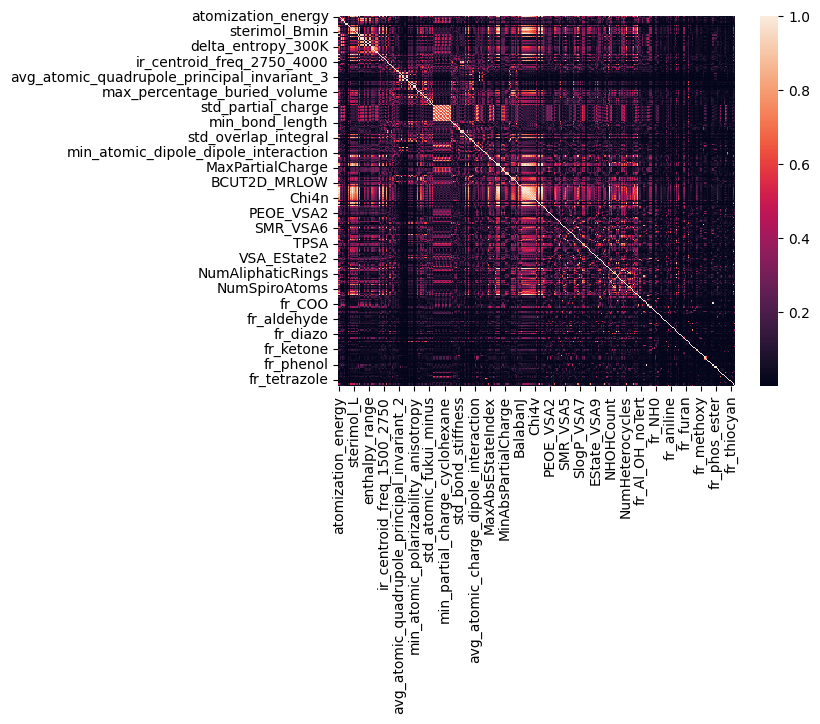

In [15]:
corr = new_X.corr().abs()

sns.heatmap(corr)

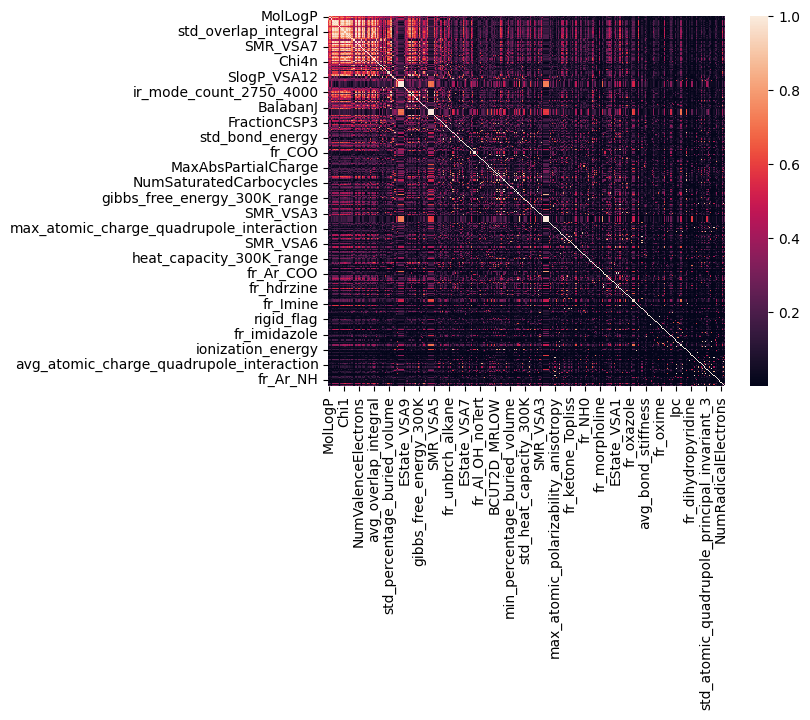

In [16]:
corr_target = new_X.corrwith(y).abs().sort_values(ascending=False)

sorted_features = corr_target.index
corr_sorted = X[sorted_features].corr()

sns.heatmap(corr_sorted.abs())
plt.show()